In [32]:

import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings('ignore')


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


In [33]:

def read_csv(file_path):
    df = pd.read_csv(file_path)
    display(df.head())

    X = df.drop('target', axis=1)
    y = df['target']
    display(y.value_counts())

    print("Shape df: ", df.shape)
    print("Shape X: ", X.shape)
    print("Shape y: ", y.shape)

    return X, y

**Original Dataset**

In [34]:
X_train, y_train = read_csv('/kaggle/input/datait/splits/raw_train.csv')
X_val, y_val = read_csv('/kaggle/input/datait/splits/raw_val.csv')
X_test, y_test = read_csv('/kaggle/input/datait/splits/raw_test.csv')

,age,trestbps,chol,thalach,oldpeak,sex,fbs,exang,cp_ATA,cp_NAP,cp_TA,restecg_Normal,restecg_ST,slope_Flat,slope_Up,target
0,0.970012,0.339016,0.127137,-0.324520,0.317046,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1
1,0.122028,-1.266031,0.099443,1.689837,-0.440356,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0
2,0.546020,-0.159102,1.244113,-0.247045,0.601071,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1
3,-0.725956,1.501291,-1.876035,-0.479470,-0.819056,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,-0.407962,0.671094,-1.876035,0.101594,-0.156330,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1


target
1    406
0    328
Name: count, dtype: int64

Shape df:  (734, 16)
Shape X:  (734, 15)
Shape y:  (734,)


,age,trestbps,chol,thalach,oldpeak,sex,fbs,exang,cp_ATA,cp_NAP,cp_TA,restecg_Normal,restecg_ST,slope_Flat,slope_Up,target
0,-0.937952,0.394362,0.191755,-0.556946,-0.819056,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0
1,-1.255946,-1.708803,0.570235,-0.556946,-0.251005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,0.440022,0.394362,-0.223649,0.915084,-0.819056,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
3,0.440022,0.172976,-0.362117,-1.447911,1.074447,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1
4,1.394004,-1.819495,0.884096,-0.440733,0.033020,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 16)
Shape X:  (92, 15)
Shape y:  (92,)


,age,trestbps,chol,thalach,oldpeak,sex,fbs,exang,cp_ATA,cp_NAP,cp_TA,restecg_Normal,restecg_ST,slope_Flat,slope_Up,target
0,-0.937952,-0.159102,0.284067,1.496148,-0.251005,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-1.573940,-0.159102,0.957945,0.140332,-0.819056,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0
2,0.970012,2.884952,-1.876035,-1.486649,-0.819056,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1
3,0.016030,0.172976,0.154830,0.140332,2.021198,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,-0.619958,-0.601874,0.662547,0.527708,1.074447,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 16)
Shape X:  (92, 15)
Shape y:  (92,)


**FE dataset**

In [35]:
X_fe_train, y_fe_train = read_csv('/kaggle/input/datait/splits/fe_train.csv')
X_fe_val, y_fe_val = read_csv('/kaggle/input/datait/splits/fe_val.csv')
X_fe_test, y_fe_test = read_csv('/kaggle/input/datait/splits/fe_test.csv')

,slope_Up_0.0,slope_Up_1.0,slope_Flat_1.0,slope_Flat_0.0,exang_1.0,exang_0.0,oldpeak,hr_ratio,cp_ATA_1.0,cp_ATA_0.0,thalach,chol,age,chol_per_age,sex_1.0,target
0,1.0,0.0,1.0,0.0,1.0,0.0,0.317046,-0.708930,1.0,0.0,-0.324520,0.127137,0.970012,-0.220020,1.0,1
1,0.0,1.0,0.0,1.0,0.0,1.0,-0.440356,0.690330,1.0,0.0,1.689837,0.099443,0.122028,-0.023516,1.0,0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.601071,-0.515395,0.0,1.0,-0.247045,1.244113,0.546020,0.785408,0.0,1
3,1.0,0.0,1.0,0.0,1.0,0.0,-0.819056,-0.025017,0.0,1.0,-0.479470,-1.876035,-0.725956,-1.736036,1.0,1
4,1.0,0.0,1.0,0.0,1.0,0.0,-0.156330,0.134758,0.0,1.0,0.101594,-1.876035,-0.407962,-1.736036,1.0,1


target
1    406
0    328
Name: count, dtype: int64

Shape df:  (734, 16)
Shape X:  (734, 15)
Shape y:  (734,)


,slope_Up_0.0,slope_Up_1.0,slope_Flat_1.0,slope_Flat_0.0,exang_1.0,exang_0.0,oldpeak,hr_ratio,cp_ATA_1.0,cp_ATA_0.0,thalach,chol,age,chol_per_age,sex_1.0,target
0,0.0,1.0,0.0,1.0,0.0,1.0,-0.819056,0.057083,1.0,0.0,-0.556946,0.191755,-0.937952,0.454851,1.0,0
1,1.0,0.0,1.0,0.0,0.0,1.0,-0.251005,0.275433,0.0,1.0,-0.556946,0.570235,-1.255946,1.040998,0.0,0
2,0.0,1.0,0.0,1.0,0.0,1.0,-0.819056,0.110652,0.0,1.0,0.915084,-0.223649,0.440022,-0.377692,1.0,0
3,1.0,0.0,1.0,0.0,1.0,0.0,1.074447,-1.075212,1.0,0.0,-1.447911,-0.362117,0.440022,-0.491520,1.0,1
4,1.0,0.0,1.0,0.0,1.0,0.0,0.033020,-0.896186,0.0,1.0,-0.440733,0.884096,1.394004,0.228143,1.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 16)
Shape X:  (92, 15)
Shape y:  (92,)


,slope_Up_0.0,slope_Up_1.0,slope_Flat_1.0,slope_Flat_0.0,exang_1.0,exang_0.0,oldpeak,hr_ratio,cp_ATA_1.0,cp_ATA_0.0,thalach,chol,age,chol_per_age,sex_1.0,target
0,1.0,0.0,1.0,0.0,0.0,1.0,-0.251005,1.385079,1.0,0.0,1.496148,0.284067,-0.937952,0.552659,0.0,0
1,0.0,1.0,0.0,1.0,0.0,1.0,-0.819056,1.047779,0.0,1.0,0.140332,0.957945,-1.573940,1.728606,1.0,0
2,0.0,1.0,0.0,1.0,1.0,0.0,-0.819056,-1.245856,0.0,1.0,-1.486649,-1.876035,0.970012,-1.736036,1.0,1
3,1.0,0.0,1.0,0.0,1.0,0.0,2.021198,-0.076552,0.0,1.0,0.140332,0.154830,0.016030,0.057101,1.0,1
4,1.0,0.0,0.0,1.0,1.0,0.0,1.074447,0.523761,0.0,1.0,0.527708,0.662547,-0.619958,0.785563,1.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 16)
Shape X:  (92, 15)
Shape y:  (92,)


Original + DT Dataset

In [36]:
X_dt_train, y_dt_train = read_csv('/kaggle/input/datait/splits/dt_train.csv')
X_dt_val, y_dt_val = read_csv('/kaggle/input/datait/splits/dt_val.csv')
X_dt_test, y_dt_test = read_csv('/kaggle/input/datait/splits/dt_test.csv')

,slope_Up,chol,thalach,age,oldpeak,trestbps,exang,cp_NAP,sex,fbs,target
0,0.0,0.127137,-0.324520,0.970012,0.317046,0.339016,1.0,0.0,1.0,1.0,1
1,1.0,0.099443,1.689837,0.122028,-0.440356,-1.266031,0.0,0.0,1.0,1.0,0
2,0.0,1.244113,-0.247045,0.546020,0.601071,-0.159102,1.0,0.0,0.0,1.0,1
3,0.0,-1.876035,-0.479470,-0.725956,-0.819056,1.501291,1.0,0.0,1.0,0.0,1
4,0.0,-1.876035,0.101594,-0.407962,-0.156330,0.671094,1.0,0.0,1.0,1.0,1


target
1    406
0    328
Name: count, dtype: int64

Shape df:  (734, 11)
Shape X:  (734, 10)
Shape y:  (734,)


,slope_Up,chol,thalach,age,oldpeak,trestbps,exang,cp_NAP,sex,fbs,target
0,1.0,0.191755,-0.556946,-0.937952,-0.819056,0.394362,0.0,0.0,1.0,1.0,0
1,0.0,0.570235,-0.556946,-1.255946,-0.251005,-1.708803,0.0,0.0,0.0,0.0,0
2,1.0,-0.223649,0.915084,0.440022,-0.819056,0.394362,0.0,1.0,1.0,0.0,0
3,0.0,-0.362117,-1.447911,0.440022,1.074447,0.172976,1.0,0.0,1.0,0.0,1
4,0.0,0.884096,-0.440733,1.394004,0.033020,-1.819495,1.0,0.0,1.0,0.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 11)
Shape X:  (92, 10)
Shape y:  (92,)


,slope_Up,chol,thalach,age,oldpeak,trestbps,exang,cp_NAP,sex,fbs,target
0,0.0,0.284067,1.496148,-0.937952,-0.251005,-0.159102,0.0,0.0,0.0,0.0,0
1,1.0,0.957945,0.140332,-1.573940,-0.819056,-0.159102,0.0,0.0,1.0,0.0,0
2,1.0,-1.876035,-1.486649,0.970012,-0.819056,2.884952,1.0,0.0,1.0,0.0,1
3,0.0,0.154830,0.140332,0.016030,2.021198,0.172976,1.0,0.0,1.0,0.0,1
4,0.0,0.662547,0.527708,-0.619958,1.074447,-0.601874,1.0,0.0,1.0,1.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 11)
Shape X:  (92, 10)
Shape y:  (92,)


**FE + DT dataset**

In [37]:
X_fe_dt_train, y_fe_dt_train = read_csv('/kaggle/input/datait/splits/fe_dt_train.csv')
X_fe_dt_val, y_fe_dt_val = read_csv('/kaggle/input/datait/splits/fe_dt_val.csv')
X_fe_dt_test, y_fe_dt_test = read_csv('/kaggle/input/datait/splits/fe_dt_test.csv')

,slope_Up_0.0,chol,bps_per_age,thalach,oldpeak,hr_ratio,age,chol_per_age,trestbps,fbs_0.0,target
0,1.0,0.127137,-0.626315,-0.324520,0.317046,-0.708930,0.970012,-0.220020,0.339016,0.0,1
1,0.0,0.099443,-1.018093,1.689837,-0.440356,0.690330,0.122028,-0.023516,-1.266031,0.0,0
2,1.0,1.244113,-0.631933,-0.247045,0.601071,-0.515395,0.546020,0.785408,-0.159102,0.0,1
3,1.0,-1.876035,1.648053,-0.479470,-0.819056,-0.025017,-0.725956,-1.736036,1.501291,1.0,1
4,1.0,-1.876035,0.690664,0.101594,-0.156330,0.134758,-0.407962,-1.736036,0.671094,0.0,1


target
1    406
0    328
Name: count, dtype: int64

Shape df:  (734, 11)
Shape X:  (734, 10)
Shape y:  (734,)


,slope_Up_0.0,chol,bps_per_age,thalach,oldpeak,hr_ratio,age,chol_per_age,trestbps,fbs_0.0,target
0,0.0,0.191755,1.091484,-0.556946,-0.819056,0.057083,-0.937952,0.454851,0.394362,0.0,0
1,1.0,0.570235,-0.204399,-0.556946,-0.251005,0.275433,-1.255946,1.040998,-1.708803,1.0,0
2,0.0,-0.223649,-0.232458,0.915084,-0.819056,0.110652,0.440022,-0.377692,0.394362,1.0,0
3,1.0,-0.362117,-0.363397,-1.447911,1.074447,-1.075212,0.440022,-0.491520,0.172976,1.0,1
4,1.0,0.884096,-1.981572,-0.440733,0.033020,-0.896186,1.394004,0.228143,-1.819495,1.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 11)
Shape X:  (92, 10)
Shape y:  (92,)


,slope_Up_0.0,chol,bps_per_age,thalach,oldpeak,hr_ratio,age,chol_per_age,trestbps,fbs_0.0,target
0,1.0,0.284067,0.669568,1.496148,-0.251005,1.385079,-0.937952,0.552659,-0.159102,1.0,0
1,0.0,0.957945,1.513399,0.140332,-0.819056,1.047779,-1.573940,1.728606,-0.159102,1.0,0
2,0.0,-1.876035,0.759979,-1.486649,-0.819056,-1.245856,0.970012,-1.736036,2.884952,1.0,1
3,1.0,0.154830,-0.033624,0.140332,2.021198,-0.076552,0.016030,0.057101,0.172976,1.0,1
4,1.0,0.662547,0.010326,0.527708,1.074447,0.523761,-0.619958,0.785563,-0.601874,0.0,1


target
1    51
0    41
Name: count, dtype: int64

Shape df:  (92, 11)
Shape X:  (92, 10)
Shape y:  (92,)


**Random Forest**

In [38]:
def find_optimal_rf(
    X_train, y_train, n_estimators_range=range(50, 501, 50),
    cv_splits=3, max_depth=5, min_samples_split=2, min_samples_leaf=1,
    max_features="sqrt", bootstrap=True, class_weight=None
):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    scores = []

    for n in n_estimators_range:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            bootstrap=bootstrap,
            class_weight=class_weight,
            n_jobs=-1,
            random_state=SEED
        )
        cv_score = cross_val_score(
            rf, X_train, y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        scores.append(cv_score.mean())

    # Lấy n_estimators tối ưu
    best_n = list(n_estimators_range)[int(np.argmax(scores))]
    print(f"n_estimators tối ưu (CV): {best_n}")

    # Vẽ biểu đồ chọn n_estimators theo CV
    plt.figure(figsize=(10, 6))
    plt.plot(list(n_estimators_range), scores, 'bo-')
    plt.title(f'Chọn n_estimators tối ưu cho Random Forest (CV={cv_splits}-fold)')
    plt.xlabel('n_estimators')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.savefig("rf.pdf", bbox_inches="tight")
    plt.show()

    # Train lại với toàn bộ X_train
    best_model = RandomForestClassifier(
        n_estimators=best_n, max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight=class_weight,
        n_jobs=-1, random_state=SEED
    )
    best_model.fit(X_train, y_train)
    return best_model, best_n, max(scores)

def evaluate_val_rf(X_train, y_train, X_val, y_val,
                    n_estimators_range=range(50, 501, 50),
                    cv_splits=3, max_depth=5, max_features="sqrt",
                    min_samples_split=2, min_samples_leaf=1,
                    bootstrap=True, class_weight=None):
    print("Tìm n_estimators tối ưu cho Random Forest...")
    rf_model, best_n, cv_acc = find_optimal_rf(
        X_train, y_train,
        n_estimators_range=n_estimators_range,
        cv_splits=cv_splits,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight=class_weight
    )

    # Dự đoán & báo cáo trên validation
    val_pred = rf_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"\nĐộ chính xác Random Forest trên tập validation: {val_acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_val, val_pred))
    return rf_model, val_acc, {"n_estimators": best_n}

def evaluate_test_rf(rf_model, X_test, y_test):
    test_pred = rf_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    print(f"\nĐộ chính xác Random Forest trên tập test: {test_acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, test_pred))
    return test_acc

**RF on Original Dataset**

Tìm n_estimators tối ưu cho Random Forest...
n_estimators tối ưu (CV): 100


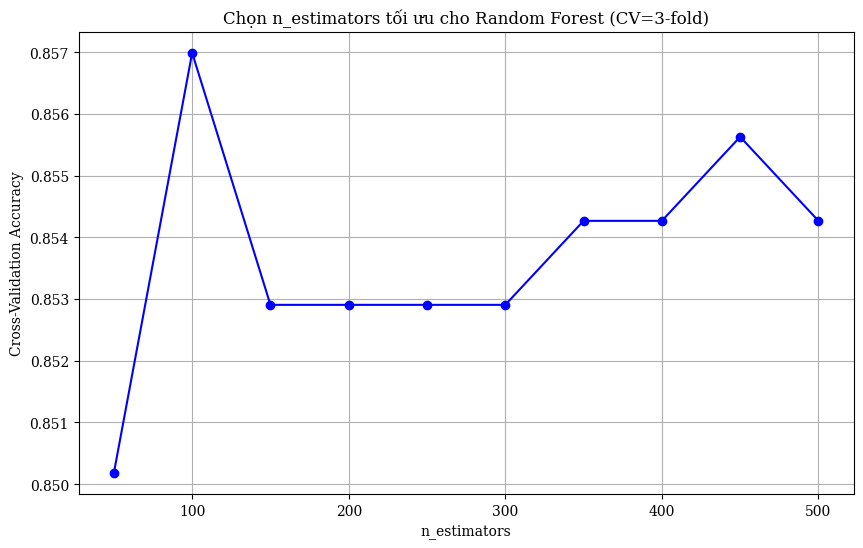


Độ chính xác Random Forest trên tập validation: 0.8478
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        41
           1       0.85      0.88      0.87        51

    accuracy                           0.85        92
   macro avg       0.85      0.84      0.85        92
weighted avg       0.85      0.85      0.85        92


Độ chính xác Random Forest trên tập test: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84        41
           1       0.83      0.96      0.89        51

    accuracy                           0.87        92
   macro avg       0.88      0.86      0.86        92
weighted avg       0.88      0.87      0.87        92



In [39]:
rf_model, val_acc, best_params = evaluate_val_rf(
    X_train, y_train, X_val, y_val)

test_acc = evaluate_test_rf(rf_model, X_test, y_test)

**RF on Feature Engineering Dataset**

Tìm n_estimators tối ưu cho Random Forest...
n_estimators tối ưu (CV): 50


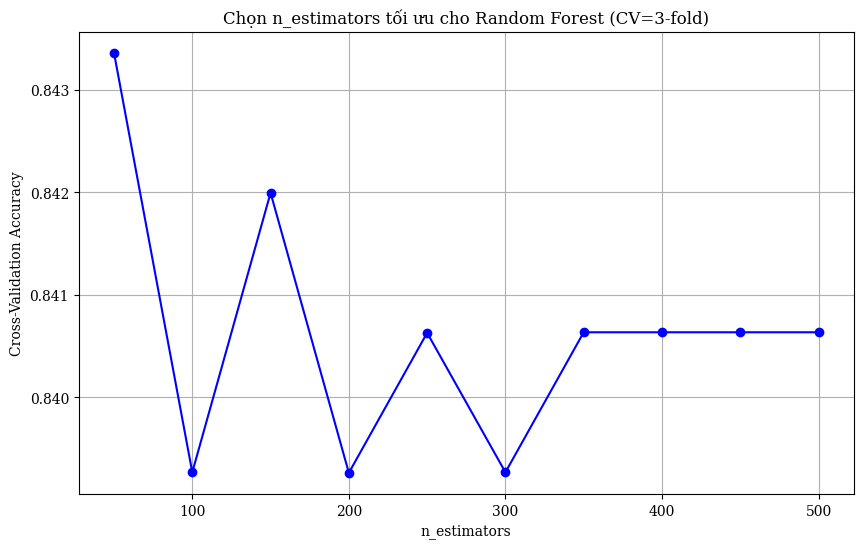


Độ chính xác Random Forest trên tập validation: 0.8478
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        41
           1       0.85      0.88      0.87        51

    accuracy                           0.85        92
   macro avg       0.85      0.84      0.85        92
weighted avg       0.85      0.85      0.85        92


Độ chính xác Random Forest trên tập test: 0.8587
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82        41
           1       0.82      0.96      0.88        51

    accuracy                           0.86        92
   macro avg       0.88      0.85      0.85        92
weighted avg       0.87      0.86      0.86        92



In [40]:
rf_model, val_fe_acc, best_params = evaluate_val_rf(
    X_fe_train, y_fe_train, X_fe_val, y_fe_val)

test_fe_acc = evaluate_test_rf(rf_model, X_fe_test, y_fe_test)

**RF on Original DT Dataset**

Tìm n_estimators tối ưu cho Random Forest...
n_estimators tối ưu (CV): 400


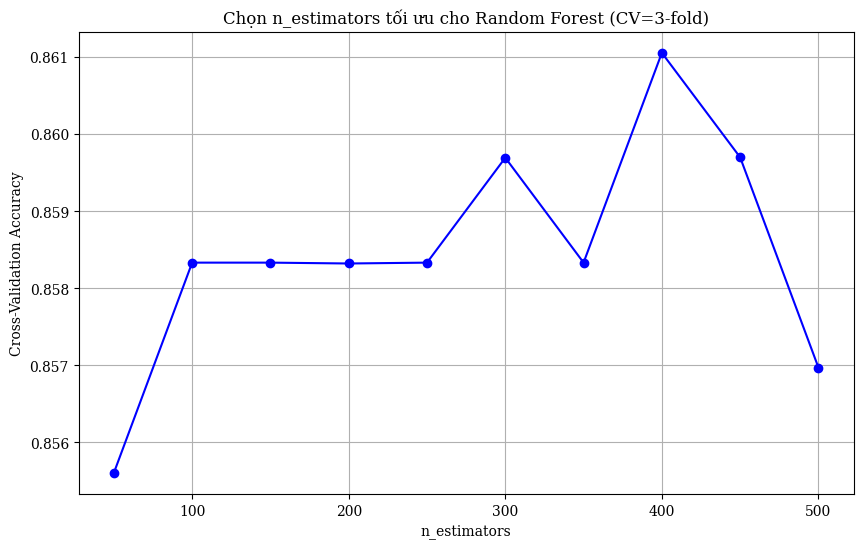


Độ chính xác Random Forest trên tập validation: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        41
           1       0.92      0.86      0.89        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92


Độ chính xác Random Forest trên tập test: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        41
           1       0.84      0.94      0.89        51

    accuracy                           0.87        92
   macro avg       0.88      0.86      0.87        92
weighted avg       0.87      0.87      0.87        92



In [41]:
rf_model, val_dt_acc, best_params = evaluate_val_rf(
    X_dt_train, y_dt_train, X_dt_val, y_dt_val)

test_dt_acc = evaluate_test_rf(rf_model, X_dt_test, y_dt_test)

**RF on Feature Engineering DT Dataset**

Tìm n_estimators tối ưu cho Random Forest...
n_estimators tối ưu (CV): 100


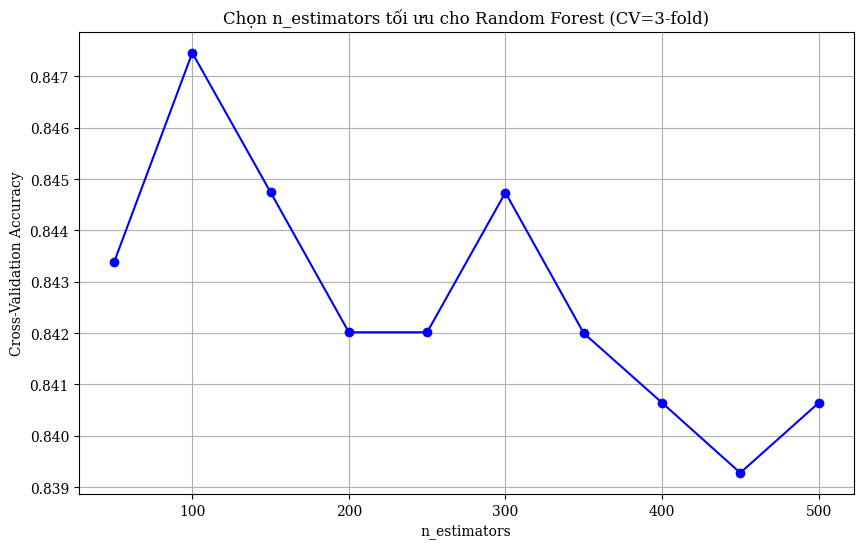


Độ chính xác Random Forest trên tập validation: 0.8152
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.78        41
           1       0.81      0.86      0.84        51

    accuracy                           0.82        92
   macro avg       0.82      0.81      0.81        92
weighted avg       0.82      0.82      0.81        92


Độ chính xác Random Forest trên tập test: 0.8370
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.68      0.79        41
           1       0.79      0.96      0.87        51

    accuracy                           0.84        92
   macro avg       0.86      0.82      0.83        92
weighted avg       0.85      0.84      0.83        92



In [42]:
rf_model, val_fe_dt_acc, best_params = evaluate_val_rf(
    X_fe_dt_train, y_fe_dt_train, X_fe_dt_val, y_fe_dt_val)

test_fe_dt_acc = evaluate_test_rf(rf_model, X_fe_dt_test, y_fe_dt_test)

**Result Visualization**

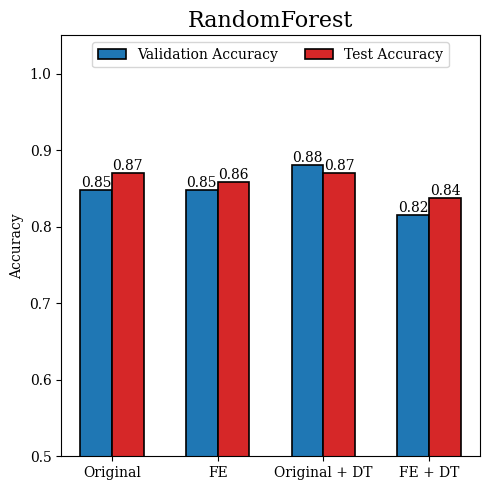

In [43]:
plt.rcParams['font.family'] = 'Serif'

labels = ['Original', 'FE', 'Original + DT', "FE + DT"]
val_accs = [val_acc, val_fe_acc, val_dt_acc, val_fe_dt_acc]
test_accs = [test_acc, test_fe_acc, test_dt_acc, test_fe_dt_acc]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))

rects1 = ax.bar(x - width/2, val_accs,  width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:red', edgecolor='black', linewidth=1.2)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('RandomForest', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
fig.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("accuracy_comparison.pdf", bbox_inches="tight")
plt.show()


**AdaBoost (AB)**

In [44]:
def find_optimal_ada(
    X_train, y_train, base_max_depth=1, algorithm="SAMME",
    n_estimators_range=range(50, 501, 50),
    cv_splits=3, learning_rate=0.1,
):
    cv = StratifiedKFold(n_splits=cv_splits,
                         shuffle=True, random_state=SEED)
    scores = []

    for n in n_estimators_range:
        ada = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=base_max_depth, random_state=SEED),
            n_estimators=n, learning_rate=learning_rate,
            algorithm=algorithm, random_state=SEED
        )
        cv_score = cross_val_score(ada, X_train, y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        scores.append(cv_score.mean())

    # Lấy n_estimators tối ưu
    best_n = list(n_estimators_range)[int(np.argmax(scores))]
    print(f"n_estimators tối ưu (CV): {best_n}")

    # Vẽ biểu đồ chọn n_estimators theo CV
    plt.figure(figsize=(10, 6))
    plt.plot(list(n_estimators_range), scores, 'bo-')
    plt.title(f'Chọn n_estimators tối ưu cho AdaBoost (CV={cv_splits}-fold)')
    plt.xlabel('n_estimators')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.show()

    # Train lại với toàn bộ X_train
    best_model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=base_max_depth, random_state=SEED),
        n_estimators=best_n, learning_rate=learning_rate,
        algorithm=algorithm, random_state=SEED
    )
    best_model.fit(X_train, y_train)
    return best_model, best_n, max(scores)

def evaluate_val_ada(X_train, y_train, X_val, y_val,
                     n_estimators_range=range(50, 501, 50),
                     cv_splits=3, learning_rate=0.1,
                     base_max_depth=1, algorithm="SAMME"):
    print("Tìm n_estimators tối ưu cho AdaBoost...")
    ada_model, best_n, cv_acc = find_optimal_ada(
        X_train, y_train,
        n_estimators_range=n_estimators_range,
        cv_splits=cv_splits,
        learning_rate=learning_rate,
        base_max_depth=base_max_depth,
        algorithm=algorithm
    )

    # Dự đoán & báo cáo trên validation
    val_pred = ada_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"\nĐộ chính xác AdaBoost trên tập validation: {val_acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_val, val_pred))
    return ada_model, val_acc, {"n_estimators": best_n}

def evaluate_test_ada(ada_model, X_test, y_test):
    test_pred = ada_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    print(f"\nĐộ chính xác AdaBoost trên tập test: {test_acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, test_pred))
    return test_acc

**AB on Original Dataset**

Tìm n_estimators tối ưu cho AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

n_estimators tối ưu (CV): 100


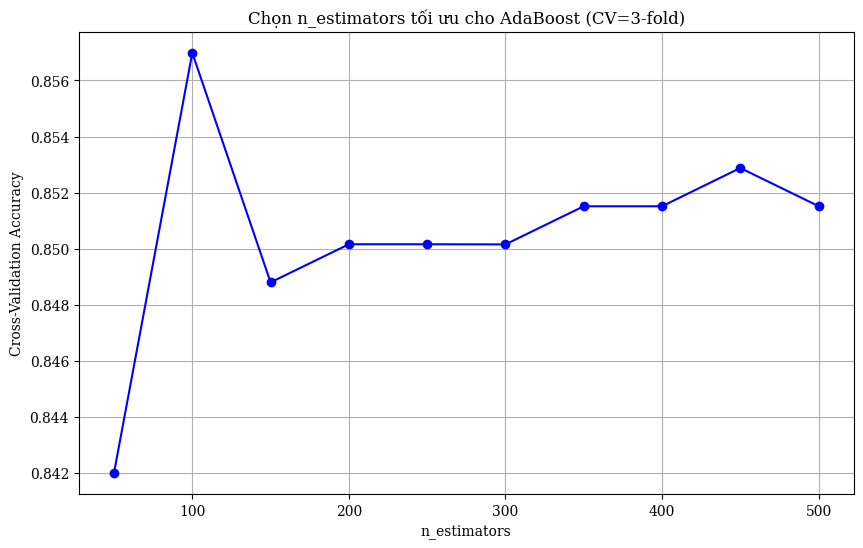


Độ chính xác AdaBoost trên tập validation: 0.8478
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        41
           1       0.86      0.86      0.86        51

    accuracy                           0.85        92
   macro avg       0.85      0.85      0.85        92
weighted avg       0.85      0.85      0.85        92


Độ chính xác AdaBoost trên tập test: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85        41
           1       0.84      0.96      0.90        51

    accuracy                           0.88        92
   macro avg       0.89      0.87      0.88        92
weighted avg       0.89      0.88      0.88        92



In [45]:
ada_model, val_acc, best_params = evaluate_val_ada(
    X_train, y_train, X_val, y_val)

test_acc = evaluate_test_ada(ada_model, X_test, y_test)

**AB on FE Dataset**

Tìm n_estimators tối ưu cho AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

n_estimators tối ưu (CV): 400


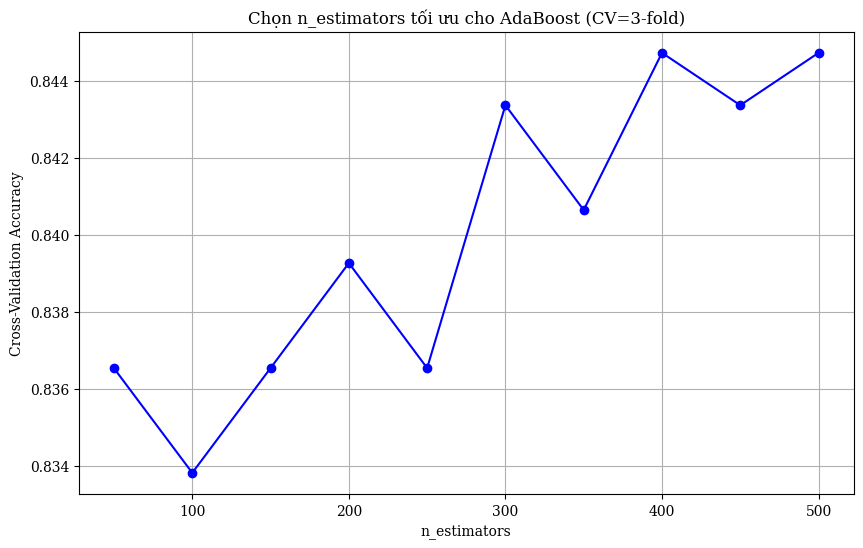


Độ chính xác AdaBoost trên tập validation: 0.8152
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        41
           1       0.85      0.80      0.83        51

    accuracy                           0.82        92
   macro avg       0.81      0.82      0.81        92
weighted avg       0.82      0.82      0.82        92


Độ chính xác AdaBoost trên tập test: 0.9130
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        41
           1       0.91      0.94      0.92        51

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92



In [46]:
ada_model, val_fe_acc, best_params = evaluate_val_ada(
    X_fe_train, y_fe_train, X_fe_val, y_fe_val)

test_fe_acc = evaluate_test_ada(ada_model, X_fe_test, y_fe_test)

**AB on Original DT Dataset**

Tìm n_estimators tối ưu cho AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

n_estimators tối ưu (CV): 150


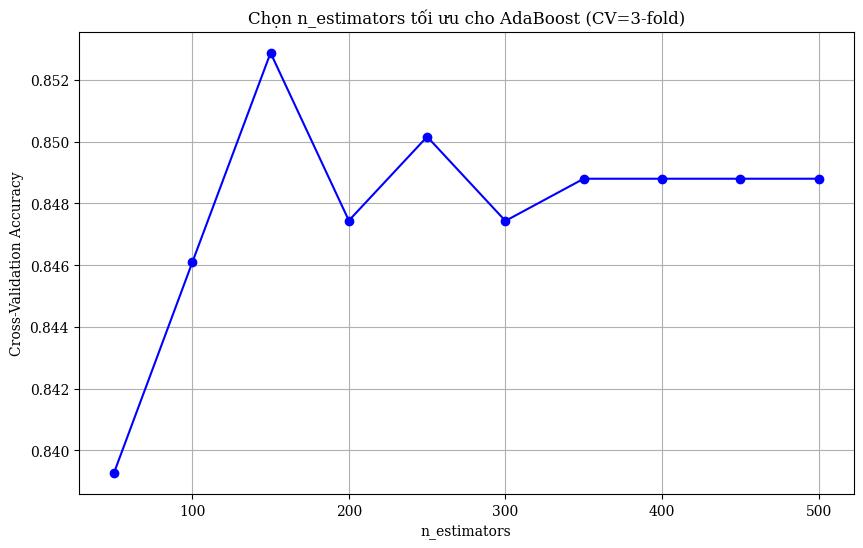


Độ chính xác AdaBoost trên tập validation: 0.8370
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        41
           1       0.88      0.82      0.85        51

    accuracy                           0.84        92
   macro avg       0.84      0.84      0.84        92
weighted avg       0.84      0.84      0.84        92


Độ chính xác AdaBoost trên tập test: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85        41
           1       0.84      0.96      0.90        51

    accuracy                           0.88        92
   macro avg       0.89      0.87      0.88        92
weighted avg       0.89      0.88      0.88        92



In [47]:
ada_model, val_dt_acc, best_params = evaluate_val_ada(
    X_dt_train, y_dt_train, X_dt_val, y_dt_val)

test_dt_acc = evaluate_test_ada(ada_model, X_dt_test, y_dt_test)

**AB on FE + DT Dataset**

Tìm n_estimators tối ưu cho AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

n_estimators tối ưu (CV): 300


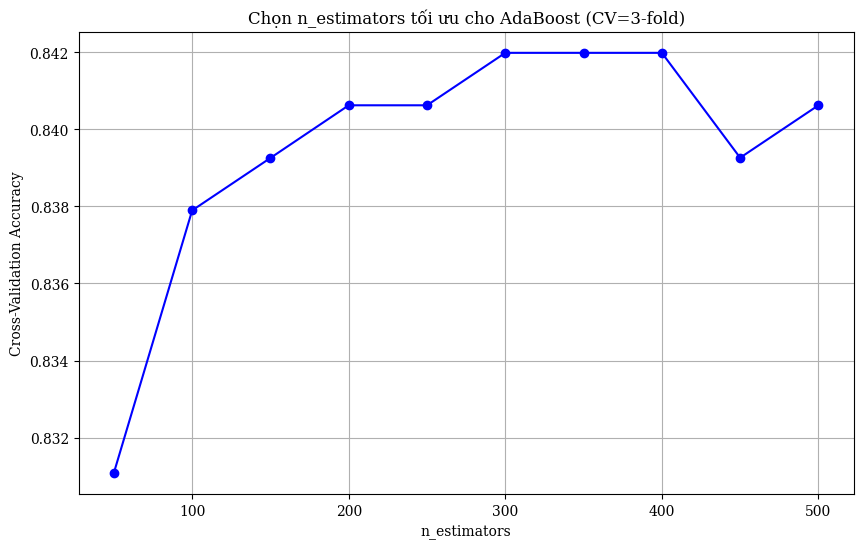


Độ chính xác AdaBoost trên tập validation: 0.8043
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        41
           1       0.82      0.82      0.82        51

    accuracy                           0.80        92
   macro avg       0.80      0.80      0.80        92
weighted avg       0.80      0.80      0.80        92


Độ chính xác AdaBoost trên tập test: 0.8370
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80        41
           1       0.81      0.92      0.86        51

    accuracy                           0.84        92
   macro avg       0.85      0.83      0.83        92
weighted avg       0.84      0.84      0.83        92



In [48]:
ada_model, val_fe_dt_acc, best_params = evaluate_val_ada(
    X_fe_dt_train, y_fe_dt_train, X_fe_dt_val, y_fe_dt_val,
)

test_fe_dt_acc = evaluate_test_ada(ada_model, X_fe_dt_test, y_fe_dt_test)

**Result Visualization**

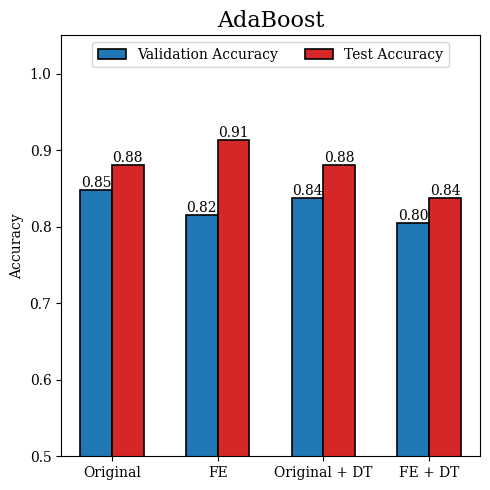

In [49]:
plt.rcParams['font.family'] = 'Serif'

labels = ['Original', 'FE', 'Original + DT', "FE + DT"]
val_accs = [val_acc, val_fe_acc, val_dt_acc, val_fe_dt_acc]
test_accs = [test_acc, test_fe_acc, test_dt_acc, test_fe_dt_acc]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))

rects1 = ax.bar(x - width/2, val_accs,  width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:red', edgecolor='black', linewidth=1.2)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('AdaBoost', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
fig.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("accuracy_comparison.pdf", bbox_inches="tight")
plt.show()


**Gradient Boost (GB)**

In [50]:

def find_optimal_gb(
    X_train, y_train,
    n_estimators_range=range(50, 501, 50),
    cv_splits=3
):
    cv = StratifiedKFold(n_splits=cv_splits,
                         shuffle=True, random_state=SEED)
    scores = []

    for n in n_estimators_range:
        gb = GradientBoostingClassifier(
            n_estimators=n, learning_rate=0.1,
            max_depth=5, subsample=1.0, random_state=SEED
        )
        cv_score = cross_val_score(
            gb, X_train, y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        scores.append(cv_score.mean())

    plt.figure(figsize=(10, 6))
    plt.plot(list(n_estimators_range), scores, 'bo-')
    plt.title(
        f'Chọn n_estimators tối ưu cho Gradient Boosting (CV={cv_splits}-fold)')
    plt.xlabel('n_estimators')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.show()

    best_n = list(n_estimators_range)[int(np.argmax(scores))]
    print(f'n_estimators tối ưu (CV): {best_n}')

    best_model = GradientBoostingClassifier(
        n_estimators=best_n,
        learning_rate=0.1,
        max_depth=5,
        subsample=1.0,
        random_state=SEED
    )
    best_model.fit(X_train, y_train)
    return best_model, best_n, max(scores)

def evaluate_val_gb(X_train, y_train, X_val, y_val,
                    n_estimators_range=range(50, 501, 50),
                    cv_splits=3):
    print('Tìm n_estimators tối ưu cho Gradient Boosting...')
    gb_model, best_n, cv_acc = find_optimal_gb(
        X_train, y_train,
        n_estimators_range=n_estimators_range,
        cv_splits=cv_splits
    )

    val_pred = gb_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f'\nĐộ chính xác GB trên tập validation: {val_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_val, val_pred))
    return gb_model, val_acc, {'n_estimators': best_n}

def evaluate_test_gb(gb_model, X_test, y_test):
    test_pred = gb_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    print(f'\nĐộ chính xác GB trên tập test: {test_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, test_pred))
    return test_acc


Tìm n_estimators tối ưu cho Gradient Boosting...


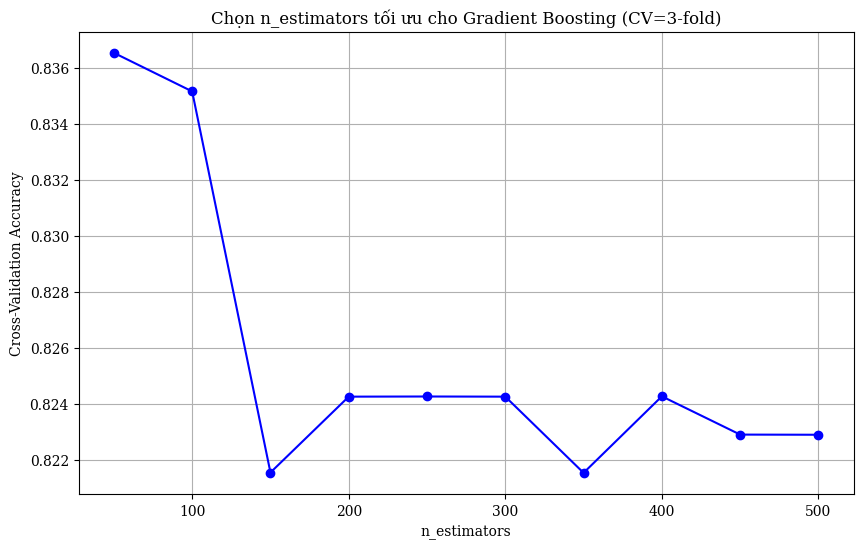

n_estimators tối ưu (CV): 50

Độ chính xác GB trên tập validation: 0.8587
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        41
           1       0.90      0.84      0.87        51

    accuracy                           0.86        92
   macro avg       0.86      0.86      0.86        92
weighted avg       0.86      0.86      0.86        92


Độ chính xác GB trên tập test: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        41
           1       0.87      0.90      0.88        51

    accuracy                           0.87        92
   macro avg       0.87      0.87      0.87        92
weighted avg       0.87      0.87      0.87        92



In [51]:

gb_model, val_acc, best_params = evaluate_val_gb(
    X_train, y_train, X_val, y_val
)


test_acc = evaluate_test_gb(gb_model, X_test, y_test)

Tìm n_estimators tối ưu cho Gradient Boosting...


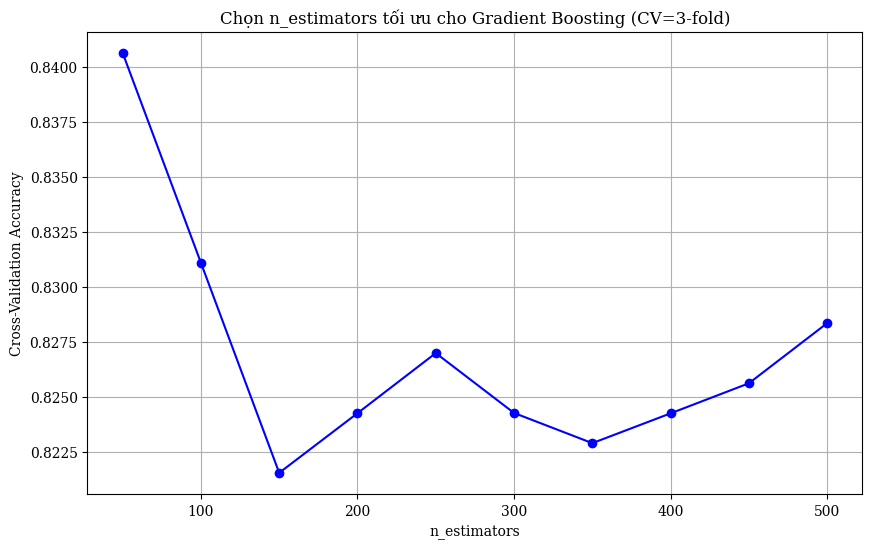

n_estimators tối ưu (CV): 50

Độ chính xác GB trên tập validation: 0.8370
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        41
           1       0.83      0.88      0.86        51

    accuracy                           0.84        92
   macro avg       0.84      0.83      0.83        92
weighted avg       0.84      0.84      0.84        92


Độ chính xác GB trên tập test: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.85        41
           1       0.85      0.92      0.89        51

    accuracy                           0.87        92
   macro avg       0.87      0.86      0.87        92
weighted avg       0.87      0.87      0.87        92



In [52]:

gb_model, val_fe_acc, best_params = evaluate_val_gb(
    X_fe_train, y_fe_train, X_fe_val, y_fe_val
)


test_fe_acc = evaluate_test_gb(gb_model, X_fe_test, y_fe_test)

Tìm n_estimators tối ưu cho Gradient Boosting...


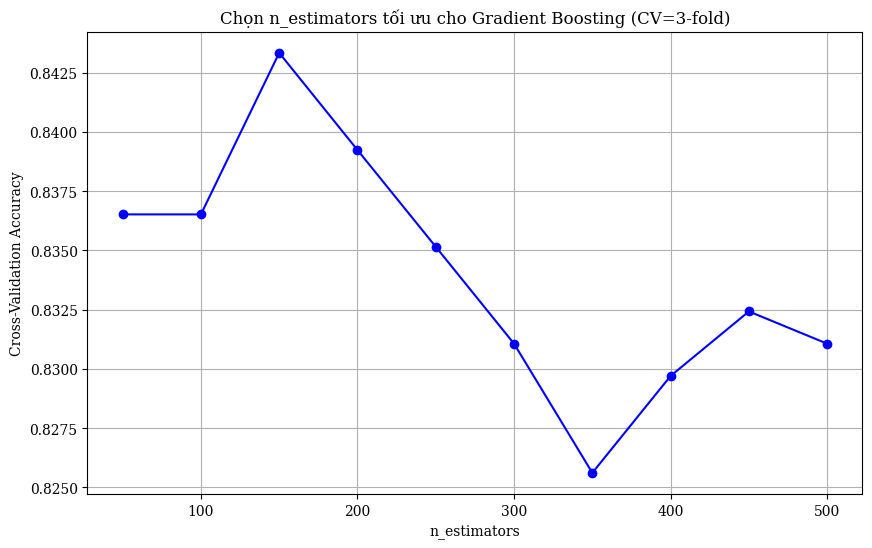

n_estimators tối ưu (CV): 150

Độ chính xác GB trên tập validation: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        41
           1       0.92      0.86      0.89        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92


Độ chính xác GB trên tập test: 0.8261
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        41
           1       0.84      0.84      0.84        51

    accuracy                           0.83        92
   macro avg       0.82      0.82      0.82        92
weighted avg       0.83      0.83      0.83        92



In [53]:

gb_model, val_dt_acc, best_params = evaluate_val_gb(
    X_dt_train, y_dt_train, X_dt_val, y_dt_val
)


test_dt_acc = evaluate_test_gb(gb_model, X_dt_test, y_dt_test)

Tìm n_estimators tối ưu cho Gradient Boosting...


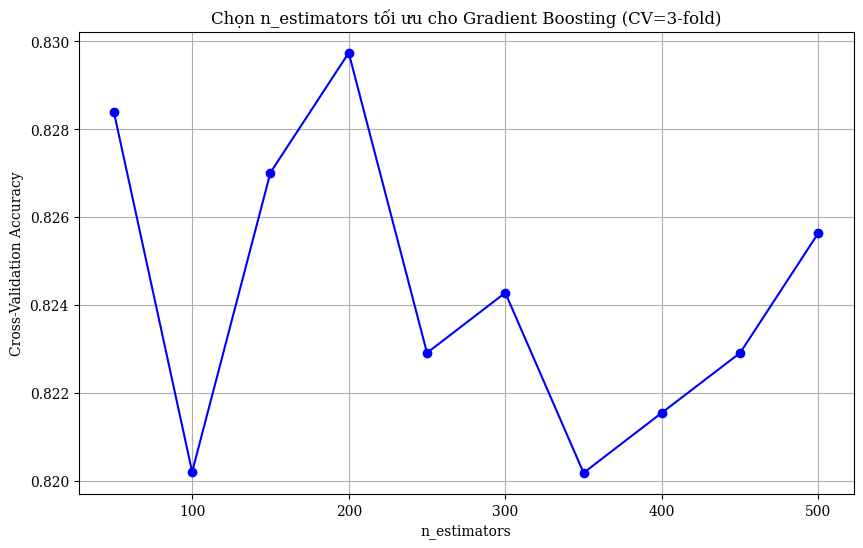

n_estimators tối ưu (CV): 200

Độ chính xác GB trên tập validation: 0.8043
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        41
           1       0.81      0.84      0.83        51

    accuracy                           0.80        92
   macro avg       0.80      0.80      0.80        92
weighted avg       0.80      0.80      0.80        92


Độ chính xác GB trên tập test: 0.8152
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        41
           1       0.80      0.88      0.84        51

    accuracy                           0.82        92
   macro avg       0.82      0.81      0.81        92
weighted avg       0.82      0.82      0.81        92



In [54]:

gb_model, val_fe_dt_acc, best_params = evaluate_val_gb(
    X_fe_dt_train, y_fe_dt_train, X_fe_dt_val, y_fe_dt_val,
)


test_fe_dt_acc = evaluate_test_gb(gb_model, X_fe_dt_test, y_fe_dt_test)

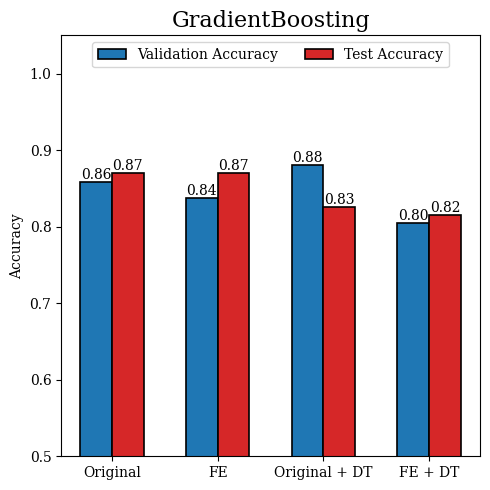

In [55]:
plt.rcParams['font.family'] = 'Serif'

labels = ['Original', 'FE', 'Original + DT', "FE + DT"]
val_accs = [val_acc, val_fe_acc, val_dt_acc, val_fe_dt_acc]
test_accs = [test_acc, test_fe_acc, test_dt_acc, test_fe_dt_acc]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))

rects1 = ax.bar(x - width/2, val_accs,  width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:red', edgecolor='black', linewidth=1.2)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('GradientBoosting', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
fig.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("accuracy_comparison.pdf", bbox_inches="tight")
plt.show()


**XGBoost**

In [56]:
# ==== 1) Tìm hyperparameters tối ưu bằng Cross-Validation ====
def find_optimal_xgb(
    X_train, y_train, n_estimators_range=range(50, 501, 50),
    cv_splits=3, learning_rate=0.1, max_depth=5, subsample=1.0, use_gpu=False
):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    scores = []

    n_classes = len(np.unique(y_train))
    objective = 'binary:logistic' if n_classes == 2 else 'multi:softprob'
    eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

    for n in n_estimators_range:
        xgb = XGBClassifier(
            n_estimators=n, learning_rate=learning_rate, max_depth=max_depth, subsample=subsample,
            objective=objective, eval_metric=eval_metric, random_state=SEED, n_jobs=-1,
            tree_method='gpu_hist' if use_gpu else 'hist', verbosity=0
        )
        cv_score = cross_val_score(
            xgb, X_train, y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        scores.append(cv_score.mean())

    plt.figure(figsize=(10, 6))
    plt.plot(list(n_estimators_range), scores, 'bo-')
    plt.title(f'Chọn n_estimators tối ưu cho XGBoost (CV={cv_splits}-fold)')
    plt.xlabel('n_estimators')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.show()

    best_n = list(n_estimators_range)[int(np.argmax(scores))]
    print(f'n_estimators tối ưu (CV): {best_n}')

    best_model = XGBClassifier(
        n_estimators=best_n, learning_rate=learning_rate,
        max_depth=max_depth, subsample=subsample, objective=objective,
        eval_metric=eval_metric, random_state=SEED, n_jobs=-1,
        tree_method='gpu_hist' if use_gpu else 'hist', verbosity=0
    )
    best_model.fit(X_train, y_train)
    return best_model, best_n, max(scores)

# ==== 2) Đánh giá trên tập validation ====
def evaluate_val_xgb(X_train, y_train, X_val, y_val,
                     n_estimators_range=range(50, 501, 50), cv_splits=3,
                     learning_rate=0.1, max_depth=5, subsample=1.0,
                     colsample_bytree=1.0, use_gpu=False):
    print('Tìm n_estimators tối ưu cho XGBoost...')
    xgb_model, best_n, cv_acc = find_optimal_xgb(
        X_train, y_train, n_estimators_range=n_estimators_range,
        cv_splits=cv_splits, learning_rate=learning_rate,
        max_depth=max_depth, subsample=subsample, use_gpu=use_gpu
    )

    val_pred = xgb_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f'\nĐộ chính xác XGBoost trên tập validation: {val_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_val, val_pred))
    return xgb_model, val_acc, {'n_estimators': best_n}

# ==== 3) Đánh giá trên tập test ====
def evaluate_test_xgb(xgb_model, X_test, y_test):
    test_pred = xgb_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    print(f'\nĐộ chính xác XGBoost trên tập test: {test_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, test_pred))
    return test_acc


Tìm n_estimators tối ưu cho XGBoost...


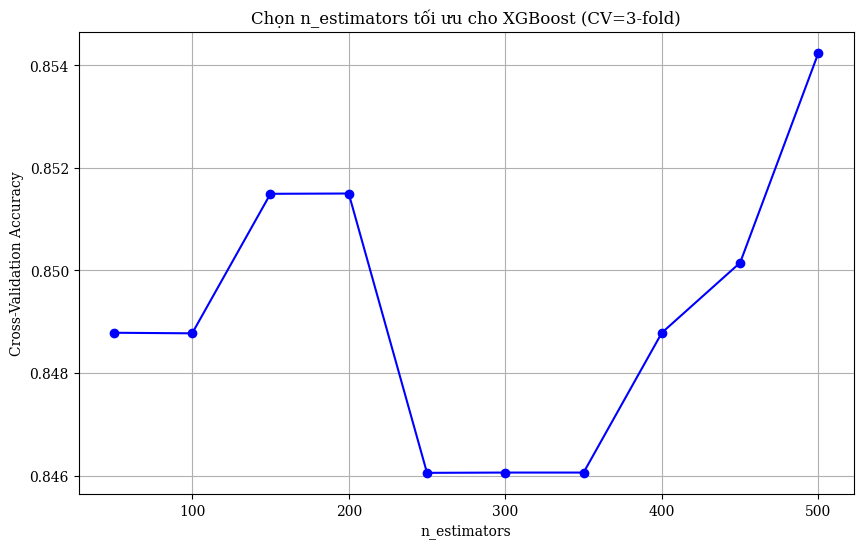

n_estimators tối ưu (CV): 500

Độ chính xác XGBoost trên tập validation: 0.8370
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        41
           1       0.88      0.82      0.85        51

    accuracy                           0.84        92
   macro avg       0.84      0.84      0.84        92
weighted avg       0.84      0.84      0.84        92


Độ chính xác XGBoost trên tập test: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        41
           1       0.88      0.90      0.89        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



In [57]:
# 1) Tìm & train model tốt nhất trên X_train
xgb_model, val_acc, best_params = evaluate_val_xgb(
    X_train, y_train, X_val, y_val
)

# 2) Đánh giá test
test_acc = evaluate_test_xgb(xgb_model, X_test, y_test)

Tìm n_estimators tối ưu cho XGBoost...


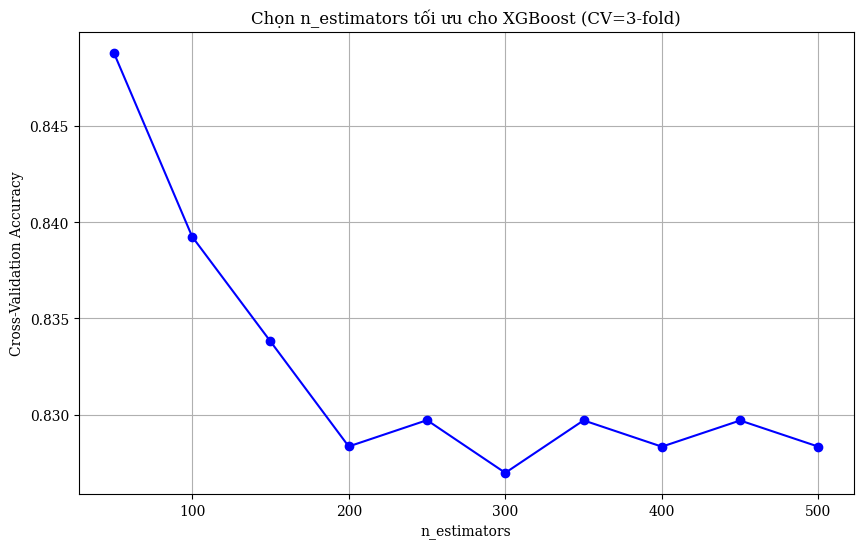

n_estimators tối ưu (CV): 50

Độ chính xác XGBoost trên tập validation: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.88      0.88      0.88        51

    accuracy                           0.87        92
   macro avg       0.87      0.87      0.87        92
weighted avg       0.87      0.87      0.87        92


Độ chính xác XGBoost trên tập test: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        41
           1       0.87      0.92      0.90        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



In [58]:
# 1) Tìm & train model tốt nhất trên X_train
xgb_model, val_fe_acc, best_params = evaluate_val_xgb(
    X_fe_train, y_fe_train, X_fe_val, y_fe_val
)

# 2) Đánh giá test
test_fe_acc = evaluate_test_xgb(xgb_model, X_fe_test, y_fe_test)

Tìm n_estimators tối ưu cho XGBoost...


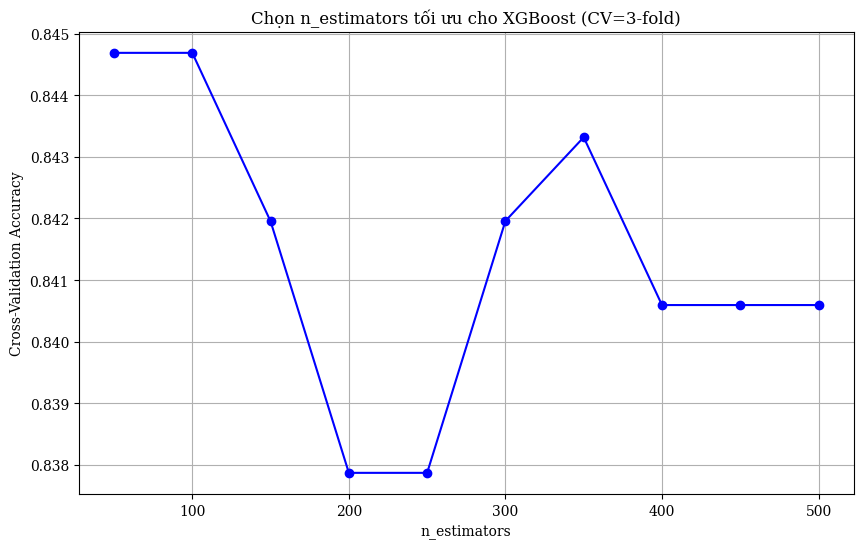

n_estimators tối ưu (CV): 50

Độ chính xác XGBoost trên tập validation: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        41
           1       0.91      0.84      0.88        51

    accuracy                           0.87        92
   macro avg       0.87      0.87      0.87        92
weighted avg       0.87      0.87      0.87        92


Độ chính xác XGBoost trên tập test: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        41
           1       0.87      0.92      0.90        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



In [59]:
# 1) Tìm & train model tốt nhất trên X_train
xgb_model, val_dt_acc, best_params = evaluate_val_xgb(
    X_dt_train, y_dt_train, X_dt_val, y_dt_val
)

# 2) Đánh giá test
test_dt_acc = evaluate_test_xgb(xgb_model, X_dt_test, y_dt_test)

Tìm n_estimators tối ưu cho XGBoost...


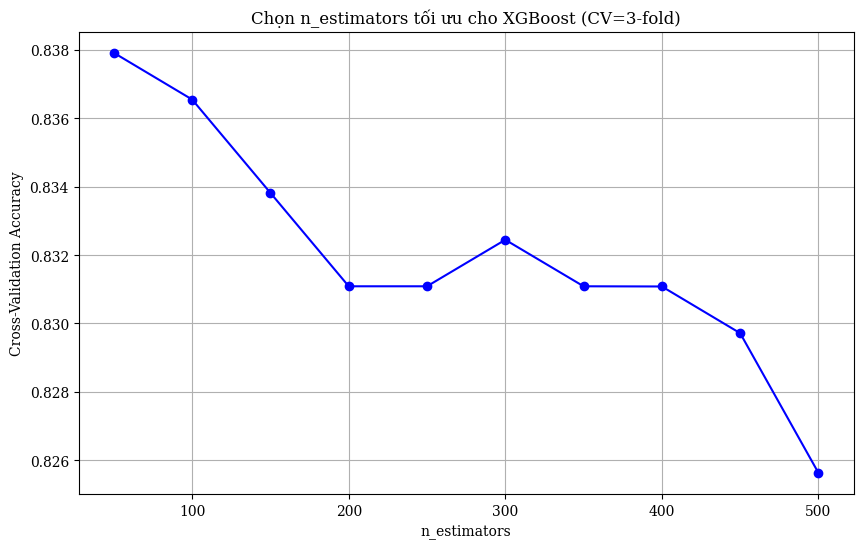

n_estimators tối ưu (CV): 50

Độ chính xác XGBoost trên tập validation: 0.8152
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        41
           1       0.85      0.80      0.83        51

    accuracy                           0.82        92
   macro avg       0.81      0.82      0.81        92
weighted avg       0.82      0.82      0.82        92


Độ chính xác XGBoost trên tập test: 0.8587
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83        41
           1       0.83      0.94      0.88        51

    accuracy                           0.86        92
   macro avg       0.87      0.85      0.85        92
weighted avg       0.87      0.86      0.86        92



In [60]:
# 1) Tìm & train model tốt nhất trên X_train
xgb_model, val_fe_dt_acc, best_params = evaluate_val_xgb(
    X_fe_dt_train, y_fe_dt_train, X_fe_dt_val, y_fe_dt_val,
)

# 2) Đánh giá test
test_fe_dt_acc = evaluate_test_xgb(xgb_model, X_fe_dt_test, y_fe_dt_test)

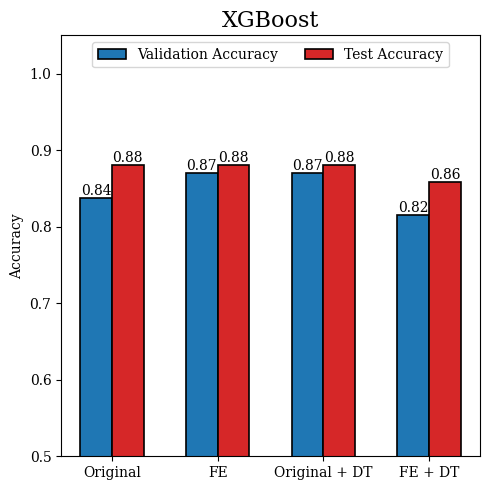

In [61]:
plt.rcParams['font.family'] = 'Serif'

labels = ['Original', 'FE', 'Original + DT', "FE + DT"]
val_accs = [val_acc, val_fe_acc, val_dt_acc, val_fe_dt_acc]
test_accs = [test_acc, test_fe_acc, test_dt_acc, test_fe_dt_acc]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))

rects1 = ax.bar(x - width/2, val_accs,  width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:red', edgecolor='black', linewidth=1.2)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('XGBoost', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
fig.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("accuracy_comparison.pdf", bbox_inches="tight")
plt.show()


Decision Tree

In [62]:


# ==== 1) Tìm hyperparameters tối ưu bằng Cross-Validation ====
def find_optimal_dt(
    X_train, y_train, max_depth_range=range(1, 21),
    cv_splits=3, criterion='gini'
):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    scores = []

    for d in max_depth_range:
        # Decision Tree tập trung vào độ sâu của cây để kiểm soát Overfitting
        dt = DecisionTreeClassifier(
            max_depth=d, 
            criterion=criterion,
            random_state=SEED
        )
        cv_score = cross_val_score(
            dt, X_train, y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        scores.append(cv_score.mean())

    plt.figure(figsize=(10, 6))
    plt.plot(list(max_depth_range), scores, 'ro-')
    plt.title(f'Chọn max_depth tối ưu cho Decision Tree (CV={cv_splits}-fold)')
    plt.xlabel('max_depth')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.show()

    best_d = list(max_depth_range)[int(np.argmax(scores))]
    print(f'max_depth tối ưu (CV): {best_d}')

    # Khởi tạo mô hình tốt nhất với độ sâu tối ưu
    best_model = DecisionTreeClassifier(
        max_depth=best_d, 
        criterion=criterion, 
        random_state=SEED
    )
    best_model.fit(X_train, y_train)
    return best_model, best_d, max(scores)

# ==== 2) Đánh giá trên tập validation ====
def evaluate_val_dt(X_train, y_train, X_val, y_val,
                    max_depth_range=range(1, 21), cv_splits=3,
                    criterion='gini'):
    print('Tìm max_depth tối ưu cho Decision Tree...')
    dt_model, best_d, cv_acc = find_optimal_dt(
        X_train, y_train, max_depth_range=max_depth_range,
        cv_splits=cv_splits, criterion=criterion
    )

    val_pred = dt_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f'\nĐộ chính xác Decision Tree trên tập validation: {val_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_val, val_pred))
    return dt_model, val_acc, {'max_depth': best_d}

# ==== 3) Đánh giá trên tập test ====
def evaluate_test_dt(dt_model, X_test, y_test):
    test_pred = dt_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    print(f'\nĐộ chính xác Decision Tree trên tập test: {test_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, test_pred))
    return test_acc

Tìm max_depth tối ưu cho Decision Tree...


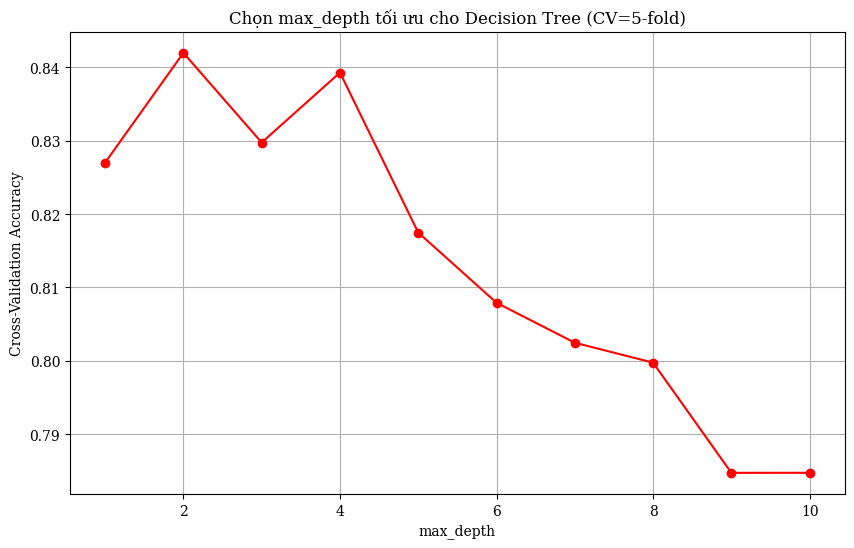

max_depth tối ưu (CV): 2

Độ chính xác Decision Tree trên tập validation: 0.7935
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        41
           1       0.80      0.84      0.82        51

    accuracy                           0.79        92
   macro avg       0.79      0.79      0.79        92
weighted avg       0.79      0.79      0.79        92


Độ chính xác Decision Tree trên tập test: 0.8261
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.63      0.76        41
           1       0.77      0.98      0.86        51

    accuracy                           0.83        92
   macro avg       0.87      0.81      0.81        92
weighted avg       0.86      0.83      0.82        92



In [63]:
# 1) Tìm & train model tốt nhất trên X_train với Decision Tree
# Sử dụng hàm evaluate_val_dt đã định nghĩa ở bước trước
dt_model, val_acc, best_params = evaluate_val_dt(
    X_train, y_train, X_val, y_val,
    max_depth_range=range(1, 11), # Thường từ 3-7 là đủ cho bộ dữ liệu này
    cv_splits=5
)

# 2) Đánh giá trên tập test
test_acc = evaluate_test_dt(dt_model, X_test, y_test)

Tìm max_depth tối ưu cho Decision Tree...


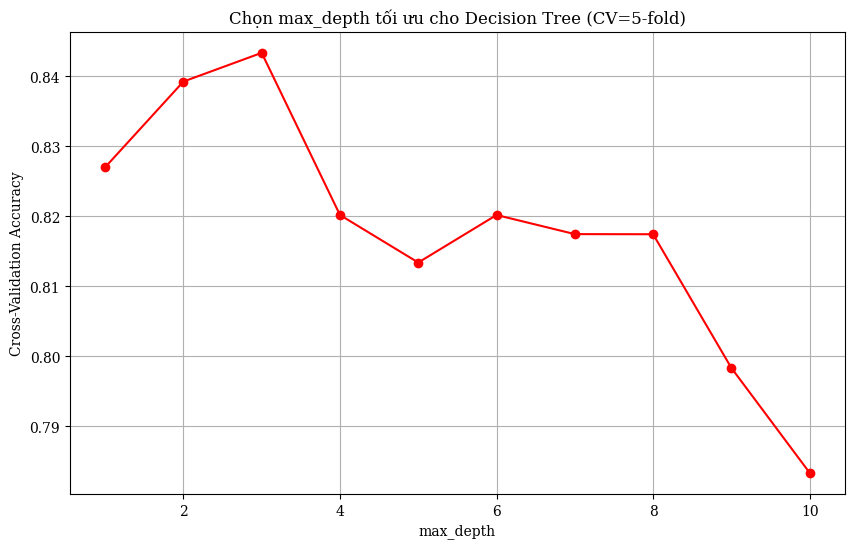

max_depth tối ưu (CV): 3

Độ chính xác Decision Tree trên tập validation: 0.8043
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        41
           1       0.81      0.84      0.83        51

    accuracy                           0.80        92
   macro avg       0.80      0.80      0.80        92
weighted avg       0.80      0.80      0.80        92


Độ chính xác Decision Tree trên tập test: 0.7935
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.66      0.74        41
           1       0.77      0.90      0.83        51

    accuracy                           0.79        92
   macro avg       0.81      0.78      0.78        92
weighted avg       0.80      0.79      0.79        92



In [64]:
# 1) Tìm & huấn luyện mô hình Decision Tree tốt nhất trên dữ liệu FE
# Chúng ta sử dụng hàm evaluate_val_dt (đã đổi tên từ xgb)
dt_fe_model, val_fe_acc, best_params_fe = evaluate_val_dt(
    X_fe_train, y_train, X_fe_val, y_val,
    max_depth_range=range(1, 11),
    cv_splits=5
)

# 2) Đánh giá trên tập kiểm thử (Test)
test_fe_acc = evaluate_test_dt(dt_fe_model, X_fe_test, y_test)

Tìm max_depth tối ưu cho Decision Tree...


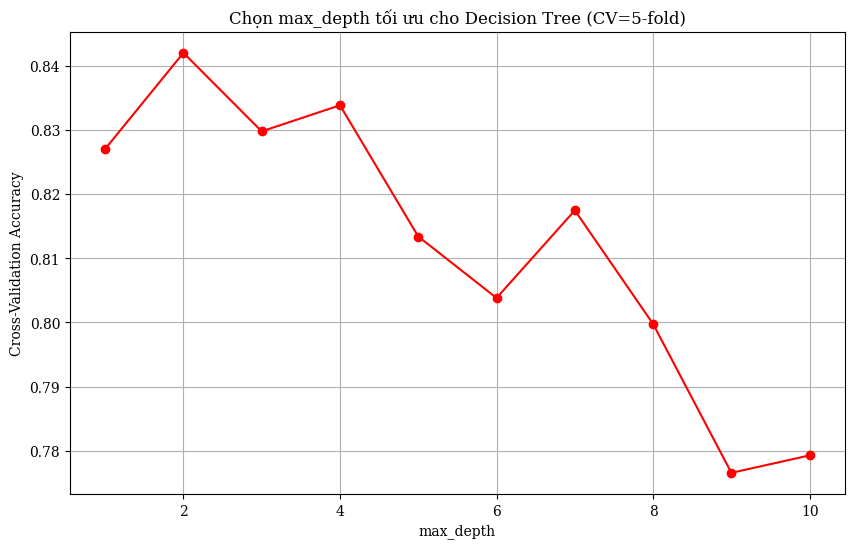

max_depth tối ưu (CV): 2

Độ chính xác Decision Tree trên tập validation: 0.7935
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        41
           1       0.80      0.84      0.82        51

    accuracy                           0.79        92
   macro avg       0.79      0.79      0.79        92
weighted avg       0.79      0.79      0.79        92


Độ chính xác Decision Tree trên tập test: 0.8261
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.63      0.76        41
           1       0.77      0.98      0.86        51

    accuracy                           0.83        92
   macro avg       0.87      0.81      0.81        92
weighted avg       0.86      0.83      0.82        92



In [65]:
# 1) Tìm & huấn luyện mô hình Decision Tree tốt nhất trên dữ liệu đã qua lựa chọn đặc trưng (DT)
# Sử dụng hàm evaluate_val_dt đã định nghĩa cho Decision Tree
dt_sel_model, val_dt_acc, best_params_dt = evaluate_val_dt(
    X_dt_train, y_train, X_dt_val, y_val,
    max_depth_range=range(1, 11),
    cv_splits=5
)

# 2) Đánh giá trên tập kiểm thử (Test)
test_dt_acc = evaluate_test_dt(dt_sel_model, X_dt_test, y_test)

Tìm max_depth tối ưu cho Decision Tree...


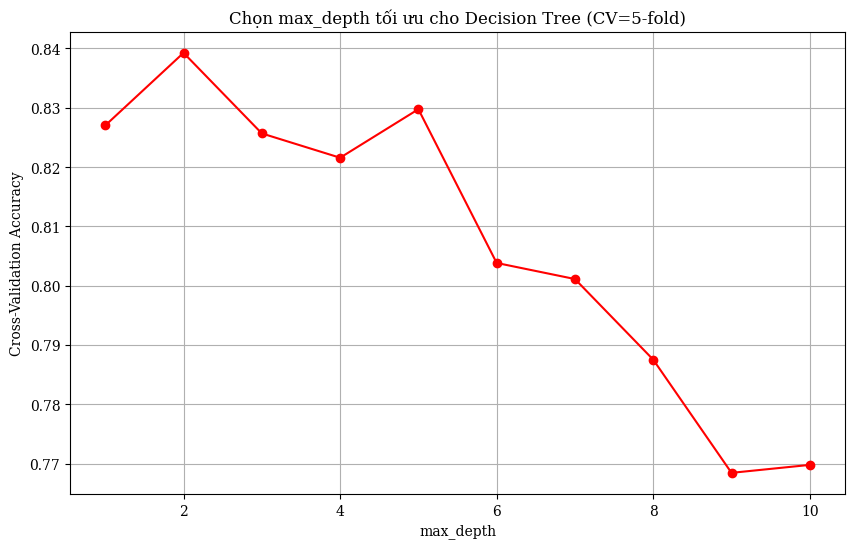

max_depth tối ưu (CV): 2

Độ chính xác Decision Tree trên tập validation: 0.7935
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        41
           1       0.80      0.84      0.82        51

    accuracy                           0.79        92
   macro avg       0.79      0.79      0.79        92
weighted avg       0.79      0.79      0.79        92


Độ chính xác Decision Tree trên tập test: 0.8261
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.63      0.76        41
           1       0.77      0.98      0.86        51

    accuracy                           0.83        92
   macro avg       0.87      0.81      0.81        92
weighted avg       0.86      0.83      0.82        92



In [66]:
# 1) Tìm & huấn luyện mô hình Decision Tree tốt nhất trên dữ liệu FE_DT
# Đây là tập dữ liệu tối ưu nhất (đã tạo thêm biến và đã lọc bớt nhiễu)
dt_fe_sel_model, val_fe_dt_acc, best_params_fe_dt = evaluate_val_dt(
    X_fe_dt_train, y_train, X_fe_dt_val, y_val,
    max_depth_range=range(1, 11),
    cv_splits=5
)

# 2) Đánh giá trên tập kiểm thử (Test)
test_fe_dt_acc = evaluate_test_dt(dt_fe_sel_model, X_fe_dt_test, y_test)

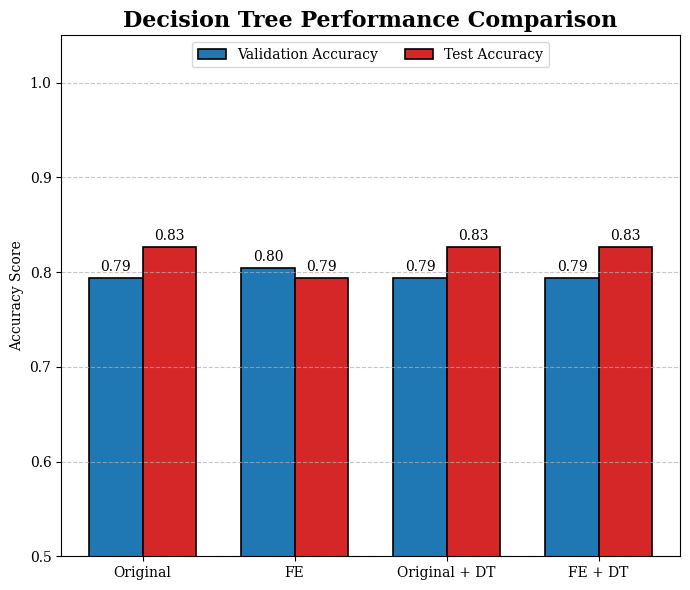

In [67]:
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['font.family'] = 'Serif'


labels = ['Original', 'FE', 'Original + DT', "FE + DT"]


val_accs = [val_acc, val_fe_acc, val_dt_acc, val_fe_dt_acc]
test_accs = [test_acc, test_fe_acc, test_dt_acc, test_fe_dt_acc]

x = np.arange(len(labels))
width = 0.35 

fig, ax = plt.subplots(figsize=(7, 6)) 


rects1 = ax.bar(x - width/2, val_accs, width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)


rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:red', edgecolor='black', linewidth=1.2)

# Định dạng trục và tiêu đề
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy Score')
ax.set_title('Decision Tree Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center", frameon=True)

# Hàm hiển thị con số trên đầu cột
def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', 
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

ax.grid(axis='y', linestyle='--', alpha=0.7) 

fig.tight_layout()

fig.savefig("dt_accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("dt_accuracy_comparison.pdf", bbox_inches="tight")

plt.show()

KNN

In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
# ==== 1) Tìm k tối ưu bằng Cross-Validation ====
def find_optimal_knn(
    X_train, y_train, k_range=range(1, 31), cv_splits=5
):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    scores = []

    for k in k_range:
        # KNN sử dụng tham số chính là n_neighbors
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        cv_score = cross_val_score(
            knn, X_train, y_train,
            cv=cv, scoring='accuracy', n_jobs=-1
        )
        scores.append(cv_score.mean())

    plt.figure(figsize=(10, 6))
    plt.plot(list(k_range), scores, 'go-') # Màu xanh lá đại diện cho KNN
    plt.title(f'Chọn n_neighbors (k) tối ưu cho KNN (CV={cv_splits}-fold)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.show()

    best_k = list(k_range)[int(np.argmax(scores))]
    print(f'Số lượng láng giềng k tối ưu (CV): {best_k}')

    # Huấn luyện mô hình tốt nhất với k đã tìm được
    best_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
    best_model.fit(X_train, y_train)
    return best_model, best_k, max(scores)

# ==== 2) Đánh giá trên tập validation ====
def evaluate_val_knn(X_train, y_train, X_val, y_val,
                     k_range=range(1, 31), cv_splits=5):
    print('Tìm k tối ưu cho KNN...')
    knn_model, best_k, cv_acc = find_optimal_knn(
        X_train, y_train, k_range=k_range, cv_splits=cv_splits
    )

    val_pred = knn_model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f'\nĐộ chính xác KNN trên tập validation: {val_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_val, val_pred))
    return knn_model, val_acc, {'n_neighbors': best_k}

# ==== 3) Đánh giá trên tập test ====
def evaluate_test_knn(knn_model, X_test, y_test):
    test_pred = knn_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    print(f'\nĐộ chính xác KNN trên tập test: {test_acc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, test_pred))
    return test_acc

Tìm k tối ưu cho KNN...


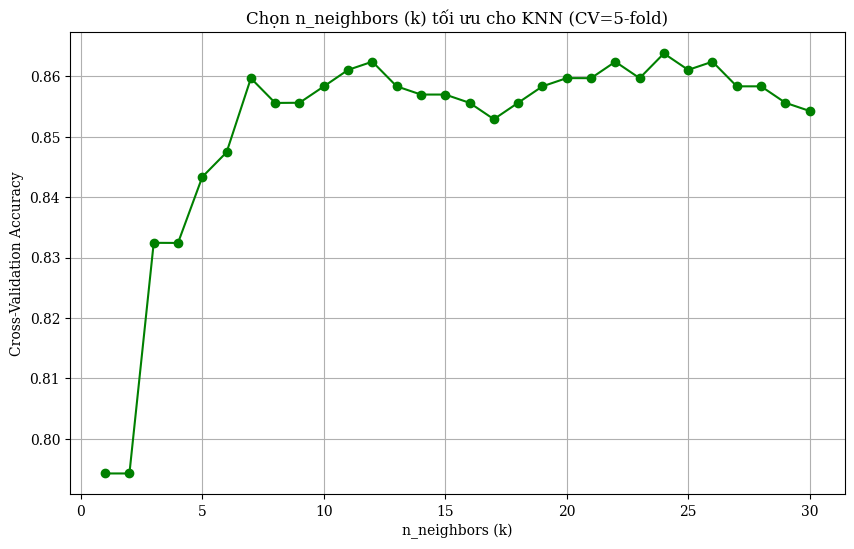

Số lượng láng giềng k tối ưu (CV): 24

Độ chính xác KNN trên tập validation: 0.8913
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        41
           1       0.90      0.90      0.90        51

    accuracy                           0.89        92
   macro avg       0.89      0.89      0.89        92
weighted avg       0.89      0.89      0.89        92


Độ chính xác KNN trên tập test: 0.9130
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90        41
           1       0.89      0.96      0.92        51

    accuracy                           0.91        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92



In [69]:
# 1) Tìm và huấn luyện mô hình KNN tốt nhất trên tập dữ liệu Gốc (X_train)
# Sử dụng hàm evaluate_val_knn đã định nghĩa ở bước trước
knn_model, val_acc, best_params = evaluate_val_knn(
    X_train, y_train, X_val, y_val,
    k_range=range(1, 31), # Thử nghiệm k từ 1 đến 30
    cv_splits=5
)

# 2) Đánh giá mô hình trên tập kiểm thử (Test)
test_acc = evaluate_test_knn(knn_model, X_test, y_test)

Tìm k tối ưu cho KNN...


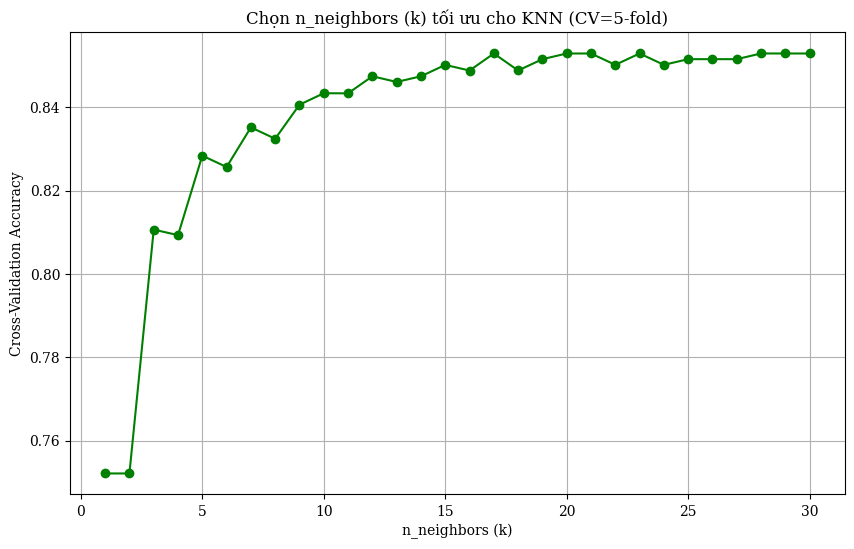

Số lượng láng giềng k tối ưu (CV): 28

Độ chính xác KNN trên tập validation: 0.8478
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        41
           1       0.85      0.88      0.87        51

    accuracy                           0.85        92
   macro avg       0.85      0.84      0.85        92
weighted avg       0.85      0.85      0.85        92


Độ chính xác KNN trên tập test: 0.8587
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82        41
           1       0.82      0.96      0.88        51

    accuracy                           0.86        92
   macro avg       0.88      0.85      0.85        92
weighted avg       0.87      0.86      0.86        92



In [70]:
# 1) Tìm và huấn luyện mô hình KNN tốt nhất trên dữ liệu đã qua kỹ thuật đặc trưng (FE)
# Sử dụng hàm evaluate_val_knn đã được định nghĩa cho thuật toán KNN
knn_fe_model, val_fe_acc, best_params_fe = evaluate_val_knn(
    X_fe_train, y_train, X_fe_val, y_val,
    k_range=range(1, 31),
    cv_splits=5
)

# 2) Đánh giá mô hình trên tập kiểm thử (Test)
test_fe_acc = evaluate_test_knn(knn_fe_model, X_fe_test, y_test)

Tìm k tối ưu cho KNN...


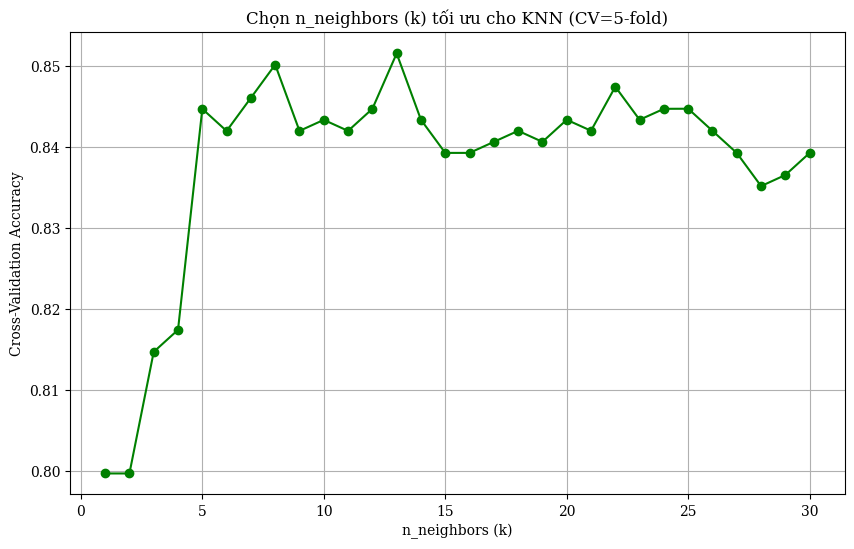

Số lượng láng giềng k tối ưu (CV): 13

Độ chính xác KNN trên tập validation: 0.8913
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        41
           1       0.92      0.88      0.90        51

    accuracy                           0.89        92
   macro avg       0.89      0.89      0.89        92
weighted avg       0.89      0.89      0.89        92


Độ chính xác KNN trên tập test: 0.8804
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        41
           1       0.88      0.90      0.89        51

    accuracy                           0.88        92
   macro avg       0.88      0.88      0.88        92
weighted avg       0.88      0.88      0.88        92



In [71]:
# 1) Tìm và huấn luyện mô hình KNN tốt nhất trên dữ liệu đã qua lựa chọn đặc trưng (DT)
# Sử dụng hàm evaluate_val_knn đã định nghĩa trước đó
knn_dt_model, val_dt_acc, best_params_dt = evaluate_val_knn(
    X_dt_train, y_train, X_dt_val, y_val,
    k_range=range(1, 31),
    cv_splits=5
)

# 2) Đánh giá trên tập kiểm thử (Test)
test_dt_acc = evaluate_test_knn(knn_dt_model, X_dt_test, y_test)

Tìm k tối ưu cho KNN...


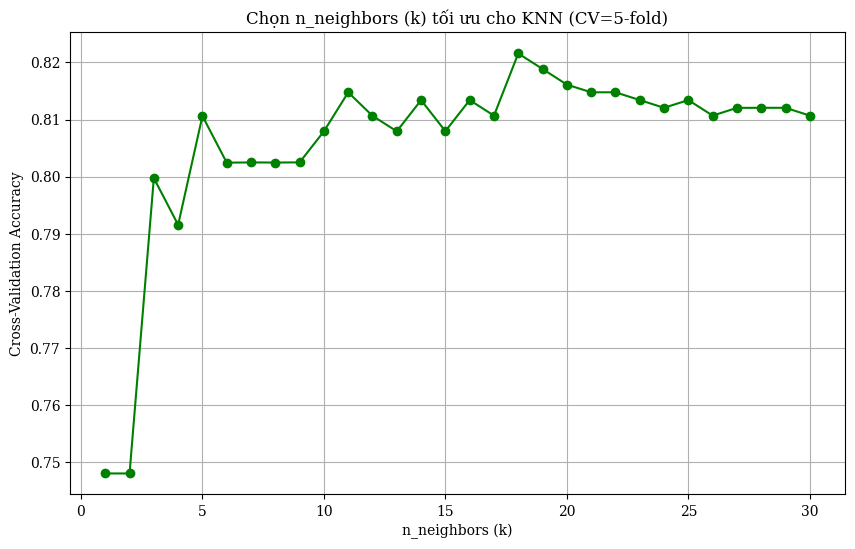

Số lượng láng giềng k tối ưu (CV): 18

Độ chính xác KNN trên tập validation: 0.8478
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        41
           1       0.88      0.84      0.86        51

    accuracy                           0.85        92
   macro avg       0.85      0.85      0.85        92
weighted avg       0.85      0.85      0.85        92


Độ chính xác KNN trên tập test: 0.8696
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.88      0.88      0.88        51

    accuracy                           0.87        92
   macro avg       0.87      0.87      0.87        92
weighted avg       0.87      0.87      0.87        92



In [72]:
# 1) Tìm và huấn luyện mô hình KNN tốt nhất trên dữ liệu FE_DT
# Đây là tập dữ liệu đã được làm giàu đặc trưng và lọc nhiễu, rất phù hợp với KNN
knn_fe_dt_model, val_fe_dt_acc, best_params_fe_dt = evaluate_val_knn(
    X_fe_dt_train, y_train, X_fe_dt_val, y_val,
    k_range=range(1, 31),
    cv_splits=5
)

# 2) Đánh giá trên tập kiểm thử (Test)
test_fe_dt_acc = evaluate_test_knn(knn_fe_dt_model, X_fe_dt_test, y_test)

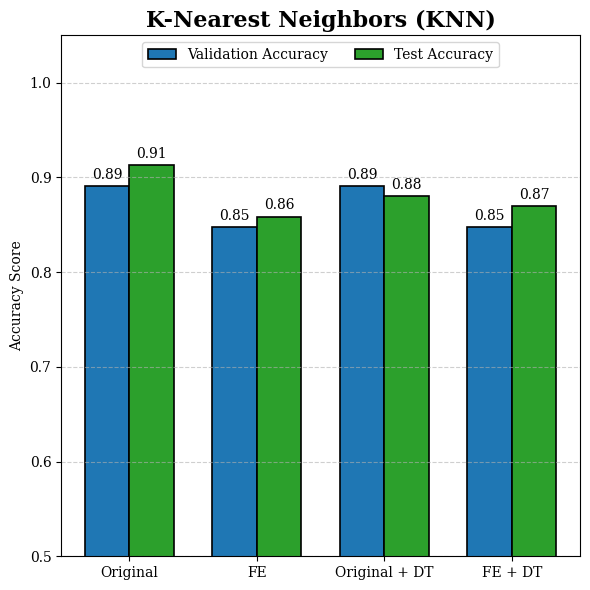

In [73]:
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['font.family'] = 'Serif'


labels = ['Original', 'FE', 'Original + DT', "FE + DT"]


val_accs = [val_acc, val_fe_acc, val_dt_acc, val_fe_dt_acc]
test_accs = [test_acc, test_fe_acc, test_dt_acc, test_fe_dt_acc]

x = np.arange(len(labels))
width = 0.35 # Điều chỉnh độ rộng cột để cân đối

fig, ax = plt.subplots(figsize=(6, 6))

# Vẽ cột cho Validation Accuracy
rects1 = ax.bar(x - width/2, val_accs,  width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)

# Vẽ cột cho Test Accuracy
rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:green', edgecolor='black', linewidth=1.2) # Đổi sang màu xanh lá cho KNN

# Định dạng các trục và tiêu đề
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy Score')
ax.set_title('K-Nearest Neighbors (KNN)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center", frameon=True)

# Hàm hiển thị giá trị trên đầu cột
def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', 
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# Thêm lưới ngang để dễ quan sát mức độ chênh lệch
ax.grid(axis='y', linestyle='--', alpha=0.6)

fig.tight_layout()

# Lưu kết quả cho báo cáo LaTeX
fig.savefig("knn_accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("knn_accuracy_comparison.pdf", bbox_inches="tight")

plt.show()

**K-means**

In [74]:
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

def get_kmeans_accuracy(X_train, y_train, X_eval, y_eval):
    # Huấn luyện K-Means trên tập Train
    kmeans = KMeans(n_clusters=2, random_state=42, init='random', n_init=10)
    kmeans.fit(X_train)
    
    # Tạo mapping từ Cluster sang Class nhãn
    train_clusters = kmeans.labels_
    cluster_map = {}
    for c_id in np.unique(train_clusters):
        # Lấy nhãn xuất hiện nhiều nhất trong cụm
        most_common = Counter(y_train[train_clusters == c_id]).most_common(1)[0][0]
        cluster_map[c_id] = most_common
        
    # Dự đoán trên tập eval và tính Accuracy
    pred_clusters = kmeans.predict(X_eval)
    y_pred = np.array([cluster_map[c] for c in pred_clusters])
    return accuracy_score(y_eval, y_pred)

In [75]:
# Danh sách lưu trữ kết quả
val_results = []
test_results = []

# Định nghĩa các cặp dữ liệu tương ứng (Train, Val, Test)
data_variants = [
    (X_train, X_val, X_test, "Original"),
    (X_fe_train, X_fe_val, X_fe_test, "FE"),
    (X_dt_train, X_dt_val, X_dt_test, "Original + DT"),
    (X_fe_dt_train, X_fe_dt_val, X_fe_dt_test, "FE + DT")
]

for X_tr, X_va, X_te, name in data_variants:
    # Tính Accuracy cho tập Val
    v_acc = get_kmeans_accuracy(X_tr, y_train, X_va, y_val)
    val_results.append(v_acc)
    
    # Tính Accuracy cho tập Test
    t_acc = get_kmeans_accuracy(X_tr, y_train, X_te, y_test)
    test_results.append(t_acc)
    
    print(f"{name} -> Val: {v_acc:.4f} | Test: {t_acc:.4f}")

Original -> Val: 0.7935 | Test: 0.7935
FE -> Val: 0.7935 | Test: 0.8696
Original + DT -> Val: 0.7717 | Test: 0.7826
FE + DT -> Val: 0.7609 | Test: 0.7935


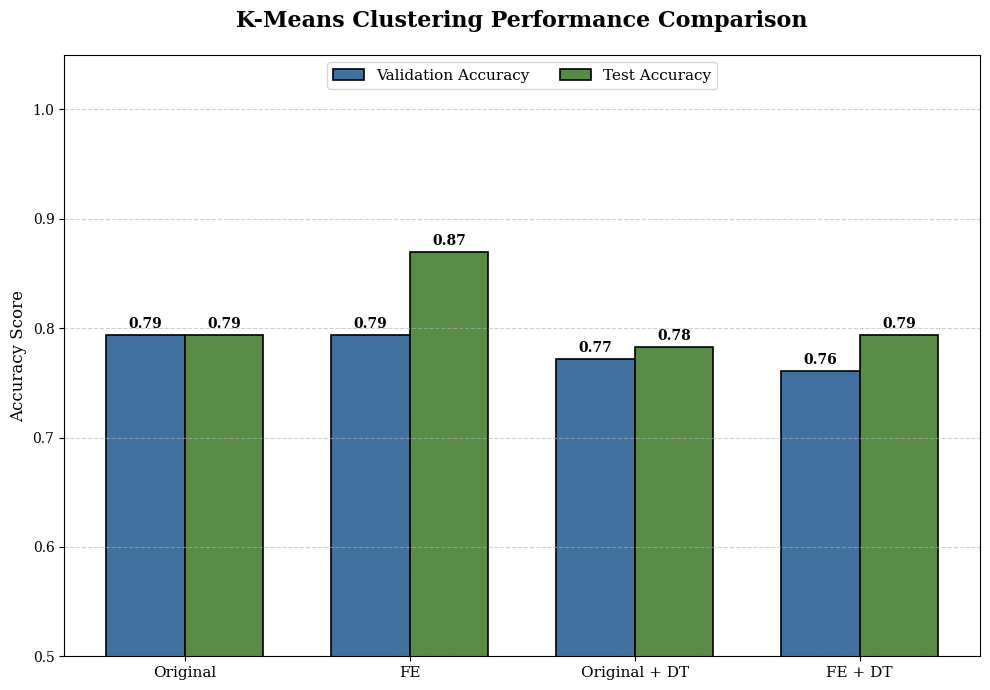

In [76]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Serif'
labels = ['Original', 'FE', 'Original + DT', 'FE + DT']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 7))

# Vẽ cột cho tập Validation 
rects1 = ax.bar(x - width/2, val_results, width, label='Validation Accuracy',
                color='#41729F', edgecolor='black', linewidth=1.2)

# Vẽ cột cho tập Test 
rects2 = ax.bar(x + width/2, test_results, width, label='Test Accuracy',
                color='#588B46', edgecolor='black', linewidth=1.2)

# Định dạng biểu đồ
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('K-Means Clustering Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(loc='upper center', ncol=2, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Hiển thị số liệu trên đầu cột
def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()